# LangGraph 멀티 에이전트 실습 — 운동 추천 시스템

**질문:** 체력이 안 좋고, 살이 계속 찌는데 어떤 운동을 할까?

| 단계 | 에이전트 | 역할 |
|------|----------|------|
| 1 | `extractor` | 사용자 질문에서 **증상 추출** |
| 2 | `recommender` | 증상에 맞는 **운동 리스트 추출** |
| 3 | `answer` | 증상 + 운동 리스트를 **개조식 답변 생성** |

In [10]:
# 필요 패키지 설치
!pip install langchain langgraph langchain-ollama

In [11]:
from langchain_ollama import OllamaLLM              # 최신 Ollama LLM 클래스
from langchain_core.prompts import PromptTemplate   # 프롬프트 템플릿
from langgraph.graph import StateGraph, END         # LangGraph 상태 머신
from typing import TypedDict                        # 타입 정의용

# ────────────────────────────────────────────────
# 1. 상태(State) 정의
#    에이전트 간에 데이터를 주고받는 '공유 그릇'
#    각 에이전트는 자신의 결과를 여기에 저장하고
#    다음 에이전트는 여기서 꺼내 씁니다.
# ────────────────────────────────────────────────
class AgentState(TypedDict):
    query: str            # 사용자 원본 질문
    symptoms: str         # 추출된 증상 목록
    exercises: str        # 추천 운동 리스트
    result: str           # 최종 개조식 답변

In [12]:
# ────────────────────────────────────────────────
# 2. LLM 초기화
#    exaone3.5:2.4b  → 한국어 특화 경량 모델 (LG AI Research)
#    로컬 Ollama 서버에서 실행됩니다.
# ────────────────────────────────────────────────
llm = OllamaLLM(model="exaone3.5:2.4b")

In [13]:
# ────────────────────────────────────────────────
# 3. 에이전트 정의
# ────────────────────────────────────────────────

# ── 에이전트 1: 증상 추출 ──────────────────────
extractor_prompt = PromptTemplate.from_template("""
사용자의 질문에서 신체적 문제(증상)에 해당하는 단어 또는 구를 추출하세요.
결과는 쉼표로 구분된 한국어 문자열로만 출력하세요. 설명은 생략합니다.

질문: {query}
""")

def extractor_agent(state: AgentState) -> AgentState:
    """사용자 질문 → 증상 키워드 추출"""
    chain = extractor_prompt | llm           # LCEL: 프롬프트 + LLM 파이프 연결
    symptoms = chain.invoke({"query": state["query"]})
    return {**state, "symptoms": symptoms.strip()}
    # 예) '체력 저하, 체중 증가, 운동 부족'


# ── 에이전트 2: 운동 추천 ──────────────────────
recommender_prompt = PromptTemplate.from_template("""
다음 증상을 가진 사람에게 적합한 운동을 5가지 추천하세요.
운동 이름만 쉼표로 구분하여 한국어로 출력하세요. 설명은 생략합니다.

증상: {symptoms}
""")

def recommender_agent(state: AgentState) -> AgentState:
    """추출된 증상 → 맞춤 운동 리스트 추천"""
    chain = recommender_prompt | llm
    exercises = chain.invoke({"symptoms": state["symptoms"]})
    return {**state, "exercises": exercises.strip()}
    # 예) '걷기, 수영, 자전거, 요가, 스트레칭'


# ── 에이전트 3: 개조식 답변 생성 ──────────────
answer_prompt = PromptTemplate.from_template("""
아래 정보를 바탕으로 사용자에게 운동을 개조식(번호 + 핵심 내용)으로 안내하세요.
반드시 한국어로 작성하며, 각 운동마다 ① 운동명 ② 추천 이유 ③ 방법/주의사항을 포함하세요.

사용자 증상: {symptoms}
추천 운동 목록: {exercises}
""")

def answer_agent(state: AgentState) -> AgentState:
    """증상 + 운동 리스트 → 개조식 최종 답변 생성"""
    chain = answer_prompt | llm
    answer = chain.invoke({
        "symptoms": state["symptoms"],
        "exercises": state["exercises"]
    })
    return {**state, "result": answer.strip()}

In [14]:
# ────────────────────────────────────────────────
# 4. LangGraph 그래프 구성
# ────────────────────────────────────────────────

graph = StateGraph(AgentState)   # AgentState를 공유 상태로 갖는 그래프 생성

# 노드 등록 (이름, 실행 함수)
graph.add_node("extractor",   extractor_agent)
graph.add_node("recommender", recommender_agent)
graph.add_node("answer",      answer_agent)

# 실행 흐름 정의
graph.set_entry_point("extractor")          # 시작 노드
graph.add_edge("extractor",   "recommender")  # extractor → recommender
graph.add_edge("recommender", "answer")        # recommender → answer
graph.add_edge("answer",      END)             # answer → 종료

app = graph.compile()   # 그래프 컴파일 → 실행 가능한 앱 객체 생성
print("✅ 그래프 컴파일 완료")

✅ 그래프 컴파일 완료


======================================== LangGraph 구조
 +-----------+   
 | __start__ |   
 +-----------+   
        *        
        *        
        *        
 +-----------+   
 | extractor |   
 +-----------+   
        *        
        *        
        *        
+-------------+  
| recommender |  
+-------------+  
        *        
        *        
        *        
  +--------+     
  | answer |     
  +--------+     
        *        
        *        
        *        
  +---------+    
  | __end__ |    
  +---------+    


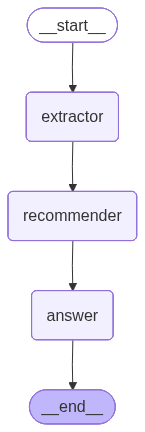

In [15]:
# ────────────────────────────────────────────────
# 5. 그래프 시각화
# ────────────────────────────────────────────────

# 5-1. ASCII 구조 출력
print("=" * 40, "LangGraph 구조")
app.get_graph().print_ascii()

# 5-2. PNG 이미지 출력 (Jupyter 환경)
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [16]:
# ────────────────────────────────────────────────
# 6. 실행
# ────────────────────────────────────────────────

query = "체력이 안 좋고, 살이 계속 찌는데 어떤 운동을 할까?"

result = app.invoke({"query": query})   # 그래프 실행 (extractor → recommender → answer)

print("=" * 40)
print("[1] 추출된 증상")
print(result["symptoms"])

print("\n" + "=" * 40)
print("[2] 추천 운동 목록")
print(result["exercises"])

print("\n" + "=" * 40)
print("[3] 최종 답변")
print(result["result"])

[1] 추출된 증상
체력 부족, 체중 증가

[2] 추천 운동 목록
가벼운 유산소 운동, 자전거 타기, 수영, 스트레칭, 가벼운 무게lifting(저강도)

[3] 최종 답변
## 체력 증진 및 체중 관리 운동 개조식 안내

**1. ① 유산소 운동 (1-5세트 × 10분씩) ② 꾸준한 심폐 기능 향상 및 체지방 감소**
* **자전거 타기:**  
    * **방법:** 평지 자전거 타기로 시작하여 속도를 점차 높여갑니다. 경사가 있는 코스에서는 중간 중간 기어를 바꾸며 심폐 지구력을 키우세요.
    * **주의사항:**  시작 전 충분한 스트레칭으로 근육 부상 예방, 점차적으로 거리와 강도 증가, 편안한 속도 유지가 중요합니다.

**2. ① 스트레칭 (전체 몸) ② 근육 이완 및 유연성 향상**
* **핵심 내용:** 모든 주요 근육군을 포함한 스트레칭으로 근육 긴장 완화 및 혈액 순환 촉진. 매일 꾸준히 실천하여 부상 예방 및 자세 개선 효과 기대.
* **방법:** 각 동작은 천천히 진행하며 15-30초씩 유지, 통증이 없는 범위 내에서 실시.

**3. ① 가벼운 무게lifting (5세트 × 8-12회 반복) ② 근육 강화 및 기초대사량 증가**
* **추천 운동 종류:** 가슴 운동 (덤벨 프레스), 어깨 운동 (덤벨 숄더 프레스), 하체 운동 (스쿼트), 복근 운동 (플랭크) 등 
* **방법:** 가벼운 무게로 시작하여 근력 증진에 집중. 올바른 자세 유지가 중요하며, 운동 후 스트레칭으로 근육 회복을 돕습니다.
* **주의사항:** 과도한 무게 사용은 피해야 하며, 부상 위험을 줄이기 위해 개인의 체력 수준에 맞는 무게 조절 필수. 전문가의 도움을 받아 올바른 자세를 익히는 것이 좋습니다.

**참고:**

* 위 운동들은 체력 수준에 따라 조절 가능합니다. 처음 시작 시에는 전문가와 상담 후 자신에게 맞는 강도와 횟수를 설정하는 것이 좋습니다.
* 꾸준한 운동과 건강한 식단 관리가 가장 중요합니다. 균형 잡힌 식단과 충분한 수분 섭취를